# BIM 430 - Derin Öğrenme Projesi
## Model 1: Kendi Tasarımımız - Multi-Kernel TextCNN

**Veri Seti:** IMDB Film Yorumları (50.000 yorum, ikili duygu sınıflandırma)

**Mimari:** Embedding → 3 paralel Conv1D (kernel 3,4,5) → GlobalMaxPool → Concat → Dense → Dropout → Sigmoid

**Önemli:** Bu model sıfırdan tasarlanmıştır. Transfer learning veya pretrained embedding KULLANILMAMIŞTIR.

## 1. Kütüphaneler ve Ayarlar

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import random

# Tekrarlanabilirlik için seed sabitleme (3 modelde de aynı olacak!)
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# GPU kontrolü
print("TensorFlow versiyonu:", tf.__version__)
print("GPU kullanılabilir:", tf.config.list_physical_devices('GPU'))

TensorFlow versiyonu: 2.19.0
GPU kullanılabilir: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Veri Yükleme ve Ön İşleme

IMDB veri seti Keras içinde hazır geliyor. Kelimeler zaten sayısal indekslere çevrilmiş durumda. Biz sadece:
- En sık 10.000 kelimeyi tutuyoruz (vocabulary size)
- Tüm yorumları 250 token uzunluğuna padleyip/kesiyoruz

In [2]:
VOCAB_SIZE = 10000
MAX_LEN = 250
EMBED_DIM = 128

# Veriyi yükle
(x_train_full, y_train_full), (x_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

print(f"Eğitim örnek sayısı: {len(x_train_full)}")
print(f"Test örnek sayısı: {len(x_test)}")
print(f"Sınıf dağılımı (eğitim): {np.bincount(y_train_full)}")
print(f"Sınıf dağılımı (test): {np.bincount(y_test)}")

# Yorum uzunluklarının dağılımı
lengths = [len(x) for x in x_train_full]
print(f"\nYorum uzunluğu - Ortalama: {np.mean(lengths):.0f}, Medyan: {np.median(lengths):.0f}, Max: {np.max(lengths)}")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Eğitim örnek sayısı: 25000
Test örnek sayısı: 25000
Sınıf dağılımı (eğitim): [12500 12500]
Sınıf dağılımı (test): [12500 12500]

Yorum uzunluğu - Ortalama: 239, Medyan: 178, Max: 2494


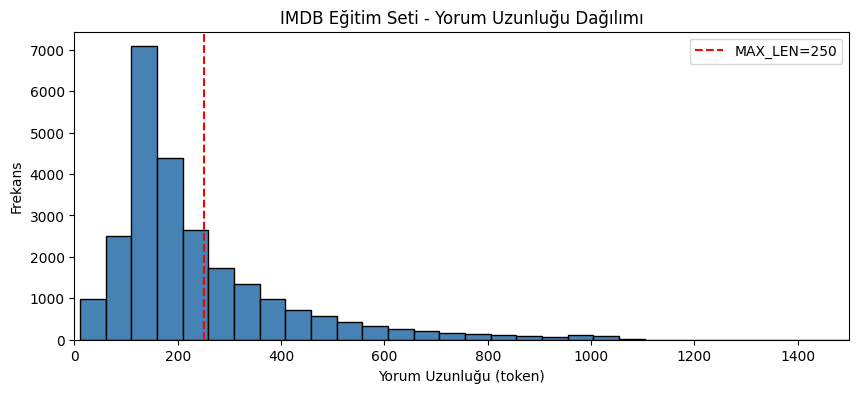

In [3]:
# Keşifsel Analiz - Yorum uzunluğu dağılımı grafiği
plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=50, color='steelblue', edgecolor='black')
plt.axvline(MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN={MAX_LEN}')
plt.xlabel('Yorum Uzunluğu (token)')
plt.ylabel('Frekans')
plt.title('IMDB Eğitim Seti - Yorum Uzunluğu Dağılımı')
plt.legend()
plt.xlim(0, 1500)
plt.show()

In [4]:
# Padding - Tüm yorumları MAX_LEN uzunluğuna eşitle
x_train_full = pad_sequences(x_train_full, maxlen=MAX_LEN, padding='post', truncating='post')
x_test = pad_sequences(x_test, maxlen=MAX_LEN, padding='post', truncating='post')

# Eğitim setinden %10'u validation için ayır
# NOT: Bu bölünme 3 modelde de AYNI olmalı (seed sabit olduğu için aynı olacak)
val_size = 2500
x_val = x_train_full[:val_size]
y_val = y_train_full[:val_size]
x_train = x_train_full[val_size:]
y_train = y_train_full[val_size:]

print(f"Eğitim: {x_train.shape}, Validation: {x_val.shape}, Test: {x_test.shape}")

Eğitim: (22500, 250), Validation: (2500, 250), Test: (25000, 250)


## 3. Model 1: Kendi Tasarımımız (Multi-Kernel TextCNN)

### Tasarım Kararları
- **Embedding (128 boyut):** Sıfırdan öğreniliyor, pretrained değil
- **3 paralel Conv1D:** Kernel boyutları 3, 4, 5 → farklı uzunluktaki n-gram desenlerini yakalar
- **ReLU aktivasyon:** Gradient vanishing'e dayanıklı, hızlı
- **GlobalMaxPooling1D:** Her filtreden en güçlü aktivasyonu seçer, konum bağımsız öznitelik
- **Concatenate:** 3 farklı ölçekten gelen öznitelikleri birleştirir (64×3=192)
- **Çift Dropout (0.5 ve 0.3):** Overfitting'e karşı iki katmanlı savunma
- **Sigmoid çıkış:** İkili sınıflandırma

In [5]:
def build_custom_textcnn():
    """Kendi tasarımımız - Multi-Kernel TextCNN"""
    inputs = keras.Input(shape=(MAX_LEN,), name='input_tokens')

    # Embedding katmanı - sıfırdan eğitilir
    x = layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        input_length=MAX_LEN,
        name='embedding'
    )(inputs)

    # Paralel Conv1D katmanları (farklı kernel boyutları)
    conv_blocks = []
    for kernel_size in [3, 4, 5]:
        conv = layers.Conv1D(
            filters=64,
            kernel_size=kernel_size,
            activation='relu',
            padding='valid',
            name=f'conv1d_k{kernel_size}'
        )(x)
        pooled = layers.GlobalMaxPooling1D(name=f'gmaxpool_k{kernel_size}')(conv)
        conv_blocks.append(pooled)

    # Birleştirme
    merged = layers.Concatenate(name='concat')(conv_blocks)

    # Regularization ve dense katmanlar
    x = layers.Dropout(0.5, name='dropout_1')(merged)
    x = layers.Dense(64, activation='relu', name='dense_hidden')(x)
    x = layers.Dropout(0.3, name='dropout_2')(x)

    # Çıkış
    outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = keras.Model(inputs, outputs, name='Custom_MultiKernel_TextCNN')
    return model

model_1 = build_custom_textcnn()
model_1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Custom_MultiKernel_TextCNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_tokens        │ (None, 250)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 250, 128)  │  1,280,000 │ input_tokens[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_k3 (Conv1D)  │ (None, 248, 64)   │     24,640 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_k4 (Conv1D)  │ (None, 247, 64)   │     32,832 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_k5 (Conv1D)  │ (None, 246, 64)   │     41,024 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmaxpool_k3         │ (None, 64)        │          0 │ conv1d_k3[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmaxpool_k4         │ (None, 64)        │          0 │ conv1d_k4[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmaxpool_k5         │ (None, 64)        │          0 │ conv1d_k5[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 192)       │          0 │ gmaxpool_k3[0][0… │
│ (Concatenate)       │                   │            │ gmaxpool_k4[0][0… │
│                     │                   │            │ gmaxpool_k5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 192)       │          0 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_hidden        │ (None, 64)        │     12,352 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_hidden[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,390,913 (5.31 MB)

 Trainable params: 1,390,913 (5.31 MB)

 Non-trainable params: 0 (0.00 B)

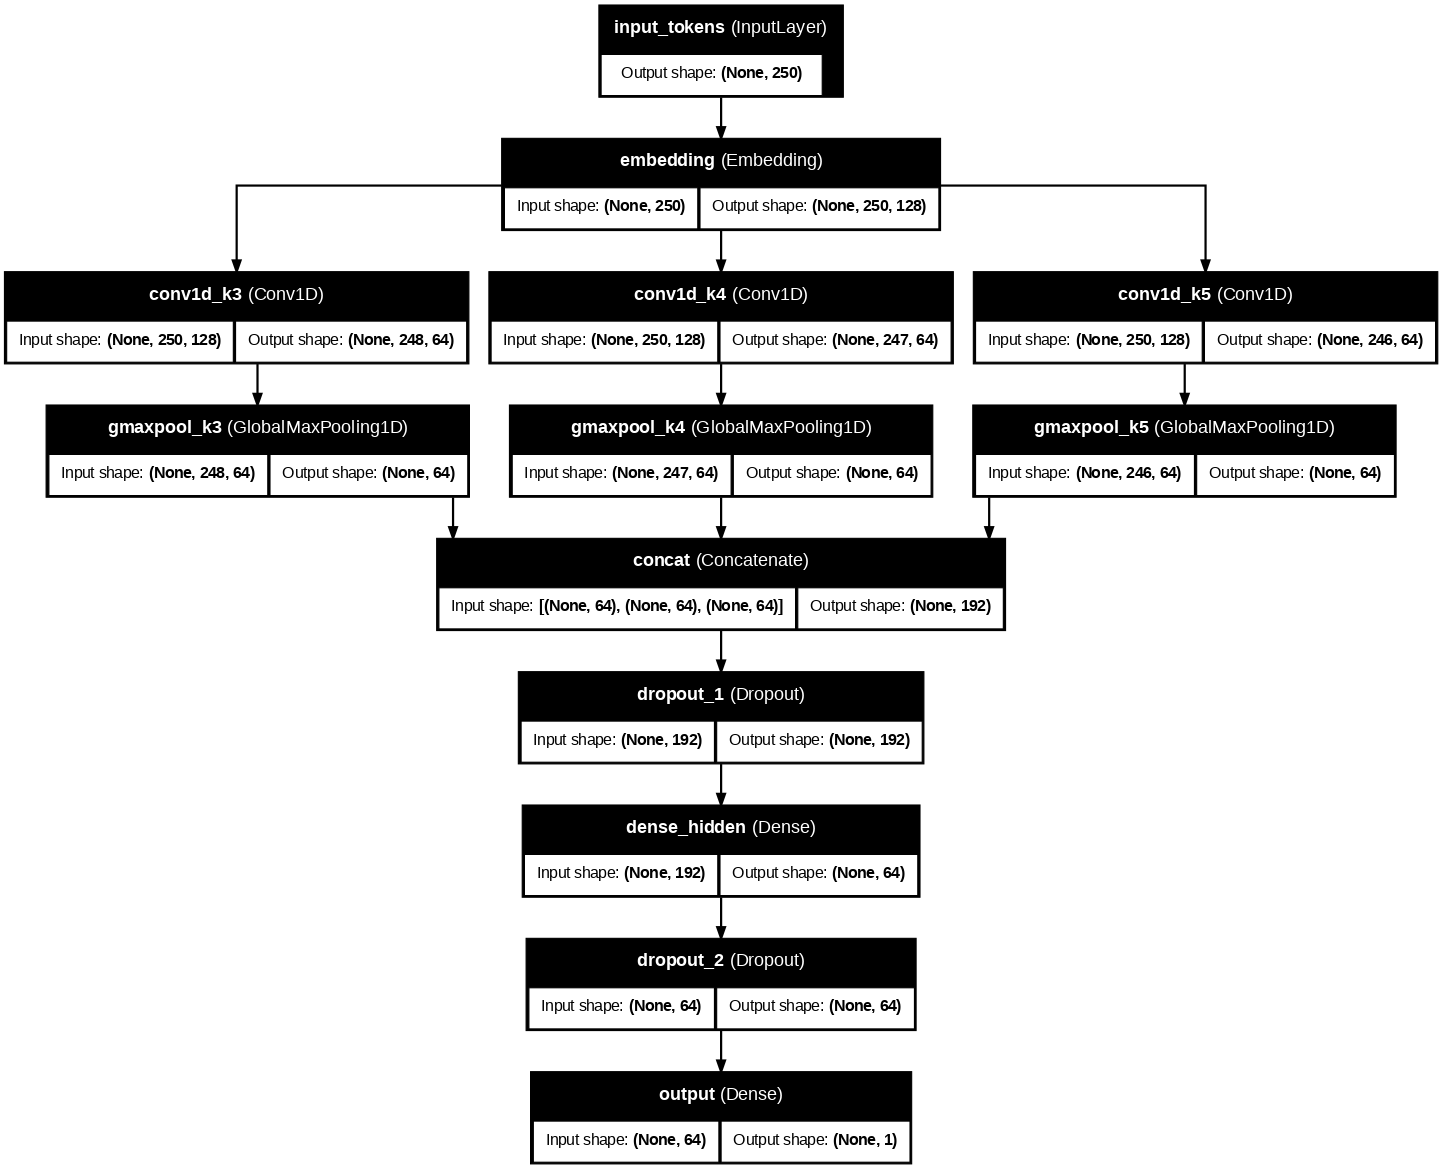

In [6]:
# Model mimarisini görselleştir (opsiyonel, sunumda kullanışlı)
keras.utils.plot_model(
    model_1,
    to_file='model1_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    dpi=80
)

## 4. Model Eğitimi

In [7]:
# Derleme
model_1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callback'ler
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Eğitim
BATCH_SIZE = 64
EPOCHS = 15

history_1 = model_1.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 23s 25ms/step - accuracy: 0.7172 - loss: 0.5281 - val_accuracy: 0.8520 - val_loss: 0.3409
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8717 - loss: 0.3082 - val_accuracy: 0.8796 - val_loss: 0.2927
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9263 - loss: 0.1971 - val_accuracy: 0.8796 - val_loss: 0.3131
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9593 - loss: 0.1163 - val_accuracy: 0.8720 - val_loss: 0.3954
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9768 - loss: 0.0710 - val_accuracy: 0.8704 - val_loss: 0.4216
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


## 5. Eğitim Grafikleri (Loss ve Accuracy)

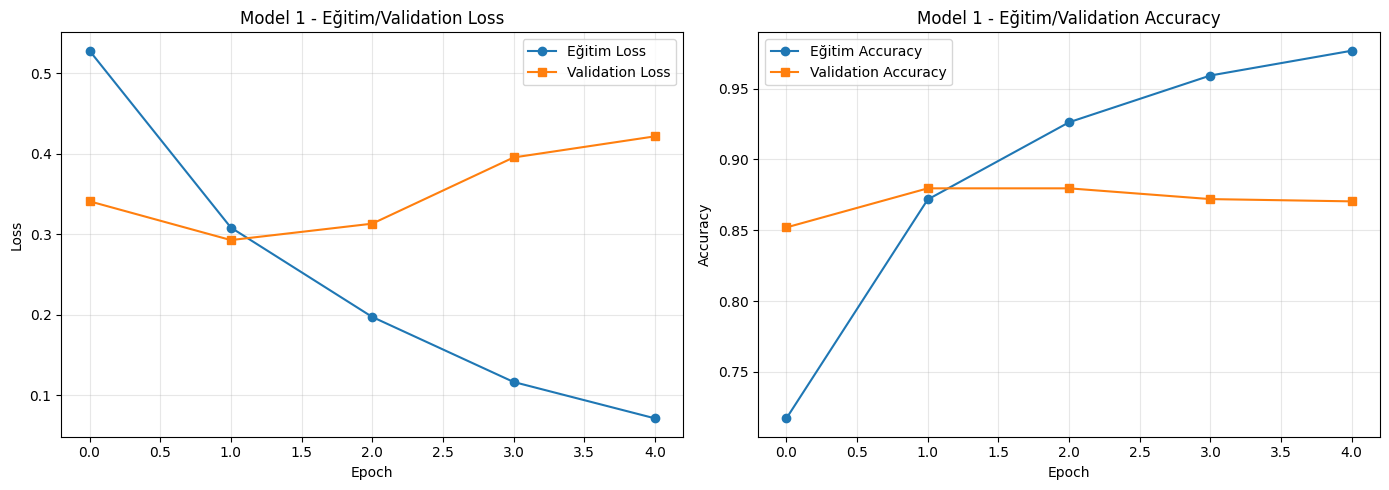

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss grafiği
axes[0].plot(history_1.history['loss'], label='Eğitim Loss', marker='o')
axes[0].plot(history_1.history['val_loss'], label='Validation Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Model 1 - Eğitim/Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy grafiği
axes[1].plot(history_1.history['accuracy'], label='Eğitim Accuracy', marker='o')
axes[1].plot(history_1.history['val_accuracy'], label='Validation Accuracy', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Model 1 - Eğitim/Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model1_training_curves.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. Test Seti Değerlendirme ve Metrikler

In [9]:
# Test seti üzerinde tahmin
y_pred_proba = model_1.predict(x_test, batch_size=BATCH_SIZE)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Metrikler
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 50)
print("MODEL 1 - Custom Multi-Kernel TextCNN - Test Sonuçları")
print("=" * 50)
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")
print("\nDetaylı Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred, target_names=['Negatif', 'Pozitif']))

391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
MODEL 1 - Custom Multi-Kernel TextCNN - Test Sonuçları
Accuracy : 0.8710
Precision: 0.8725
Recall   : 0.8690
F1-Score : 0.8707

Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

     Negatif       0.87      0.87      0.87     12500
     Pozitif       0.87      0.87      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



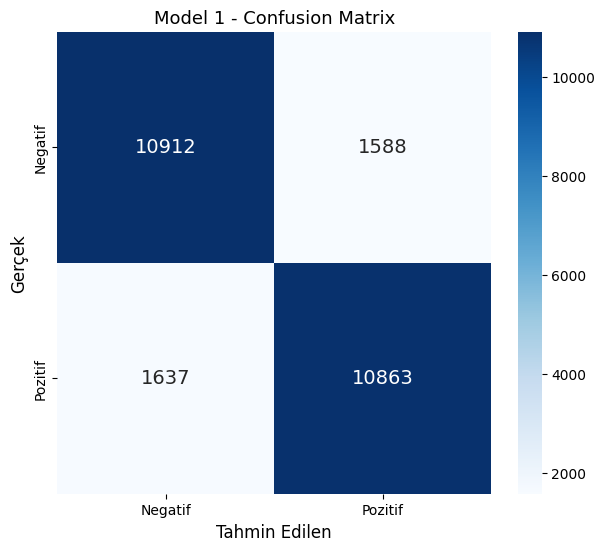

In [10]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatif', 'Pozitif'],
            yticklabels=['Negatif', 'Pozitif'],
            cbar=True, annot_kws={'size': 14})
plt.xlabel('Tahmin Edilen', fontsize=12)
plt.ylabel('Gerçek', fontsize=12)
plt.title('Model 1 - Confusion Matrix', fontsize=13)
plt.savefig('model1_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

In [11]:
# Sonuçları sonraki notebook'larda karşılaştırmak için kaydet
results_model_1 = {
    'model_name': 'Custom Multi-Kernel TextCNN',
    'accuracy': float(acc),
    'precision': float(prec),
    'recall': float(rec),
    'f1_score': float(f1),
    'confusion_matrix': cm.tolist(),
    'history': {k: [float(v) for v in vals] for k, vals in history_1.history.items()}
}

import json
with open('results_model_1.json', 'w') as f:
    json.dump(results_model_1, f, indent=2)

# Modeli de kaydet
model_1.save('model_1_custom_textcnn.keras')
print("Model ve sonuçlar kaydedildi!")

Model ve sonuçlar kaydedildi!


## 7. Sonuç Yorumu

(Bu kısmı sunum/rapor için kendi gözlemlerinle doldur)

- Model X epoch'ta early stopping ile durdu
- Validation loss Y epoch'tan sonra artmaya başladı → overfitting belirtisi
- Accuracy ~%87-88 civarında bekleniyor
- Confusion matrix'te hangi sınıfta daha çok hata yapıldı?

### Bir sonraki adım: Model 2 (LSTM) ve Model 3 (BiLSTM) aynı veri seti üzerinde eğitilecek.

In [12]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_PATH = '/content/drive/MyDrive/deeplearning/model1'
os.makedirs(SAVE_PATH, exist_ok=True)
print(f"Kayıt klasörü: {SAVE_PATH}")
print("Mevcut dosyalar:", os.listdir(SAVE_PATH))

Mounted at /content/drive
Kayıt klasörü: /content/drive/MyDrive/deeplearning/model1
Mevcut dosyalar: ['model1_custom_textcnn.ipynb']


In [13]:
# IMDB veri setindeki sayısal indeksleri kelimelere çevirelim
word_index = imdb.get_word_index()
# Keras indekslerinde ilk 3 indeks özel: 0=padding, 1=start, 2=unknown
reverse_word_index = {value + 3: key for key, value in word_index.items()}
reverse_word_index[0] = '<PAD>'
reverse_word_index[1] = '<START>'
reverse_word_index[2] = '<UNK>'
reverse_word_index[3] = '<UNUSED>'

def decode_review(encoded_review):
    """Sayısal indeksleri okunabilir metne çevir"""
    return ' '.join([reverse_word_index.get(i, '?') for i in encoded_review if i != 0])

# 5 pozitif ve 5 negatif örnek gösterelim
print("="*80)
print("VERİ SETİ ÖRNEKLERİ")
print("="*80)

# Orijinal eğitim verisini tekrar yükleyelim (padding öncesi hali için)
(x_train_raw, y_train_raw), _ = imdb.load_data(num_words=VOCAB_SIZE)

pozitif_idx = np.where(y_train_raw == 1)[0][:3]
negatif_idx = np.where(y_train_raw == 0)[0][:3]

print("\n🟢 POZİTİF YORUM ÖRNEKLERİ:\n")
for i, idx in enumerate(pozitif_idx, 1):
    review = decode_review(x_train_raw[idx])
    print(f"Örnek {i} (uzunluk: {len(x_train_raw[idx])} token):")
    print(f"{review[:400]}...")
    print("-" * 80)

print("\n🔴 NEGATİF YORUM ÖRNEKLERİ:\n")
for i, idx in enumerate(negatif_idx, 1):
    review = decode_review(x_train_raw[idx])
    print(f"Örnek {i} (uzunluk: {len(x_train_raw[idx])} token):")
    print(f"{review[:400]}...")
    print("-" * 80)

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VERİ SETİ ÖRNEKLERİ

🟢 POZİTİF YORUM ÖRNEKLERİ:

Örnek 1 (uzunluk: 218 token):
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it...
--------------------------------------------------------------------------------
Örnek 2 (uzunluk: 550 token):
<START> the <UNK> <UNK> at storytelling the traditional sort many years after the event i can still see in my <UNK> eye an elderly lady my friend's mother retelling the battle of <UNK> she makes the characters come alive her passion is that of an eye witness one to the events on the <UNK> heath a mile or so from where she lives br br of course it happened

VERİ SETİ ÖZET BİLGİLERİ
Kaynak: Keras IMDB Dataset (Maas et al., 2011)
Toplam örnek sayısı: 50000
  - Eğitim: 22500 örnek
  - Validation: 2500 örnek
  - Test: 25000 örnek
Sınıf sayısı: 2 (Pozitif / Negatif)
Kelime dağarcığı: 10000 kelime (en sık kullanılanlar)
Maksimum dizi uzunluğu: 250 token
Sınıf dengesi: Dengeli (50/50)


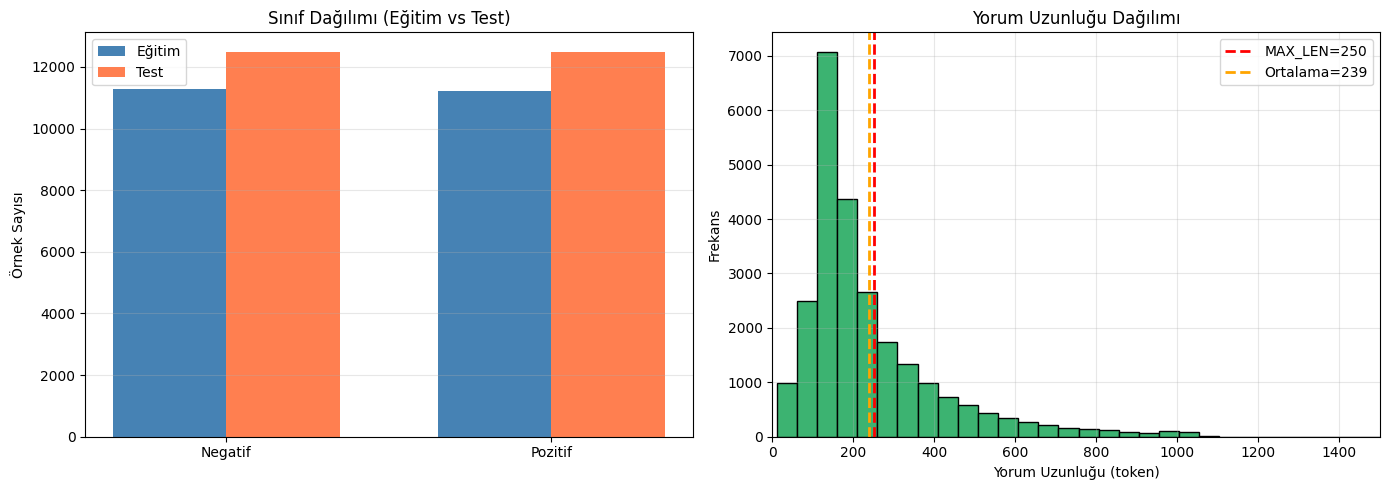

In [15]:
import pandas as pd

# Veri seti özet bilgileri
print("="*60)
print("VERİ SETİ ÖZET BİLGİLERİ")
print("="*60)
print(f"Kaynak: Keras IMDB Dataset (Maas et al., 2011)")
print(f"Toplam örnek sayısı: {len(x_train_raw) + len(x_test)}")
print(f"  - Eğitim: {len(x_train)} örnek")
print(f"  - Validation: {len(x_val)} örnek")
print(f"  - Test: {len(x_test)} örnek")
print(f"Sınıf sayısı: 2 (Pozitif / Negatif)")
print(f"Kelime dağarcığı: {VOCAB_SIZE} kelime (en sık kullanılanlar)")
print(f"Maksimum dizi uzunluğu: {MAX_LEN} token")
print(f"Sınıf dengesi: Dengeli (50/50)")

# Görsel: sınıf dağılımı + uzunluk dağılımı
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sınıf dağılımı
class_counts_train = np.bincount(y_train)
class_counts_test = np.bincount(y_test)
x_labels = ['Negatif', 'Pozitif']
x_pos = np.arange(len(x_labels))
width = 0.35

axes[0].bar(x_pos - width/2, class_counts_train, width, label='Eğitim', color='steelblue')
axes[0].bar(x_pos + width/2, class_counts_test, width, label='Test', color='coral')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(x_labels)
axes[0].set_ylabel('Örnek Sayısı')
axes[0].set_title('Sınıf Dağılımı (Eğitim vs Test)')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Kelime uzunluğu dağılımı (ham veri üzerinde)
lengths_raw = [len(x) for x in x_train_raw]
axes[1].hist(lengths_raw, bins=50, color='mediumseagreen', edgecolor='black')
axes[1].axvline(MAX_LEN, color='red', linestyle='--', linewidth=2, label=f'MAX_LEN={MAX_LEN}')
axes[1].axvline(np.mean(lengths_raw), color='orange', linestyle='--', linewidth=2, label=f'Ortalama={np.mean(lengths_raw):.0f}')
axes[1].set_xlabel('Yorum Uzunluğu (token)')
axes[1].set_ylabel('Frekans')
axes[1].set_title('Yorum Uzunluğu Dağılımı')
axes[1].legend()
axes[1].set_xlim(0, 1500)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/dataset_overview.png', dpi=100, bbox_inches='tight')
plt.show()

✅ JSON kaydedildi: /content/drive/MyDrive/deeplearning/model1/results_model_1.json
✅ Model kaydedildi: /content/drive/MyDrive/deeplearning/model1/model_1_custom_textcnn.keras


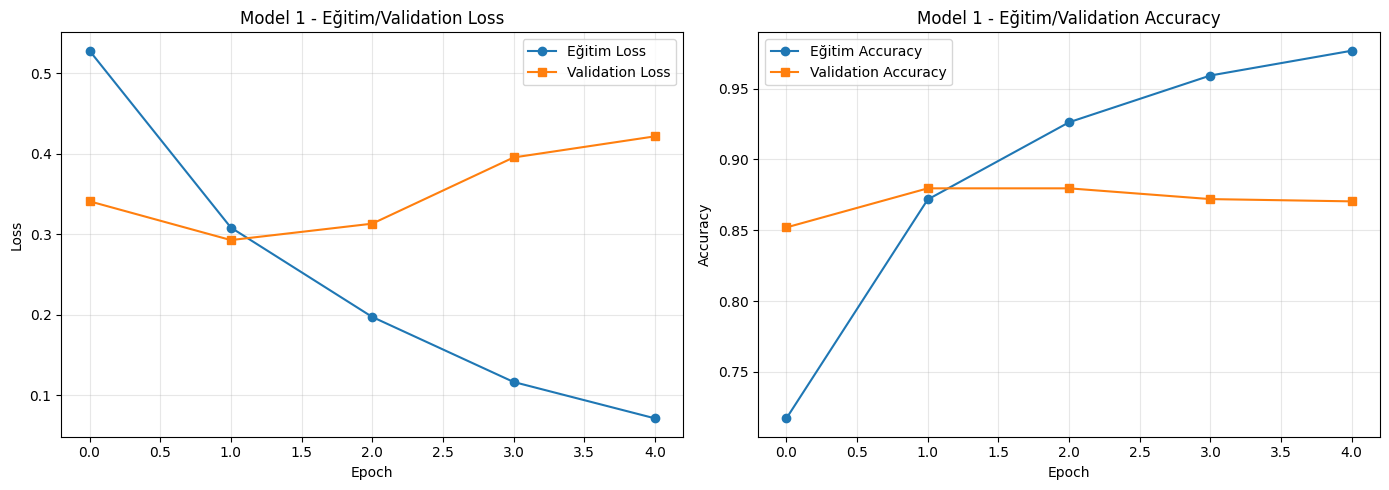

✅ Training curves kaydedildi


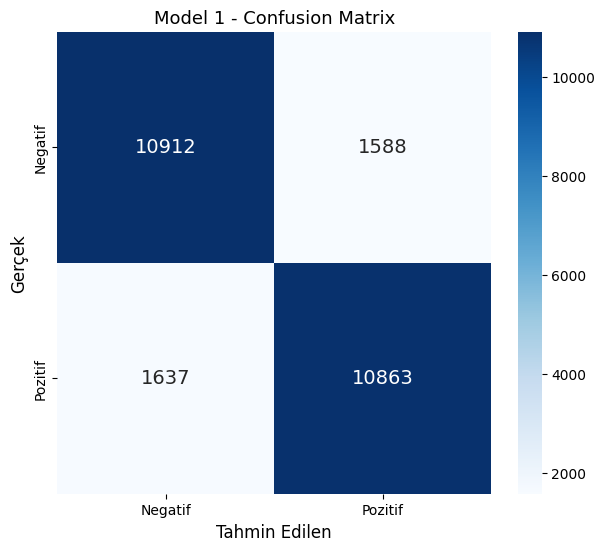

✅ Confusion matrix kaydedildi

TÜM DOSYALAR KAYDEDİLDİ!
Konum: /content/drive/MyDrive/deeplearning/model1
Dosyalar:
  📄 dataset_overview.png (47.8 KB)
  📄 model1_confusion_matrix.png (25.8 KB)
  📄 model1_custom_textcnn.ipynb (315.4 KB)
  📄 model1_training_curves.png (61.2 KB)
  📄 model_1_custom_textcnn.keras (16356.9 KB)
  📄 results_model_1.json (1.1 KB)


In [16]:
import json

# Metrikleri JSON olarak kaydet
results_model_1 = {
    'model_name': 'Custom Multi-Kernel TextCNN',
    'accuracy': float(acc),
    'precision': float(prec),
    'recall': float(rec),
    'f1_score': float(f1),
    'confusion_matrix': cm.tolist(),
    'history': {k: [float(v) for v in vals] for k, vals in history_1.history.items()},
    'hyperparameters': {
        'vocab_size': VOCAB_SIZE,
        'max_len': MAX_LEN,
        'embed_dim': EMBED_DIM,
        'batch_size': BATCH_SIZE,
        'optimizer': 'Adam',
        'learning_rate': 1e-3,
        'seed': SEED
    }
}

# JSON dosyasını Drive'a kaydet
json_path = f'{SAVE_PATH}/results_model_1.json'
with open(json_path, 'w') as f:
    json.dump(results_model_1, f, indent=2)
print(f"✅ JSON kaydedildi: {json_path}")

# Modeli Drive'a kaydet
model_path = f'{SAVE_PATH}/model_1_custom_textcnn.keras'
model_1.save(model_path)
print(f"✅ Model kaydedildi: {model_path}")

# Grafikleri de Drive'a yeniden kaydet
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_1.history['loss'], label='Eğitim Loss', marker='o')
axes[0].plot(history_1.history['val_loss'], label='Validation Loss', marker='s')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Model 1 - Eğitim/Validation Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_1.history['accuracy'], label='Eğitim Accuracy', marker='o')
axes[1].plot(history_1.history['val_accuracy'], label='Validation Accuracy', marker='s')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Model 1 - Eğitim/Validation Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/model1_training_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"✅ Training curves kaydedildi")

# Confusion matrix
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatif', 'Pozitif'],
            yticklabels=['Negatif', 'Pozitif'],
            cbar=True, annot_kws={'size': 14})
plt.xlabel('Tahmin Edilen', fontsize=12)
plt.ylabel('Gerçek', fontsize=12)
plt.title('Model 1 - Confusion Matrix', fontsize=13)
plt.savefig(f'{SAVE_PATH}/model1_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"✅ Confusion matrix kaydedildi")

print("\n" + "="*60)
print("TÜM DOSYALAR KAYDEDİLDİ!")
print("="*60)
print(f"Konum: {SAVE_PATH}")
print("Dosyalar:")
for f in sorted(os.listdir(SAVE_PATH)):
    filepath = f'{SAVE_PATH}/{f}'
    size_kb = os.path.getsize(filepath) / 1024
    print(f"  📄 {f} ({size_kb:.1f} KB)")

In [17]:
print("="*80)
print("MODEL TAHMİNLERİ - GERÇEK ÖRNEKLER ÜZERİNDE")
print("="*80)

# Test setinden orijinal (padding öncesi) metinleri almak için
_, (x_test_raw, y_test_raw) = imdb.load_data(num_words=VOCAB_SIZE)

# 3 doğru, 3 yanlış tahmin gösterelim
dogru_idx = np.where(y_pred == y_test)[0][:3]
yanlis_idx = np.where(y_pred != y_test)[0][:3]

print("\n✅ DOĞRU TAHMİNLER:\n")
for idx in dogru_idx:
    review_text = decode_review(x_test_raw[idx])[:300]
    gercek = 'Pozitif' if y_test[idx] == 1 else 'Negatif'
    tahmin = 'Pozitif' if y_pred[idx] == 1 else 'Negatif'
    guven = y_pred_proba[idx][0]
    print(f"Gerçek: {gercek} | Tahmin: {tahmin} | Güven: {guven:.3f}")
    print(f"Yorum: {review_text}...")
    print("-"*80)

print("\n❌ YANLIŞ TAHMİNLER:\n")
for idx in yanlis_idx:
    review_text = decode_review(x_test_raw[idx])[:300]
    gercek = 'Pozitif' if y_test[idx] == 1 else 'Negatif'
    tahmin = 'Pozitif' if y_pred[idx] == 1 else 'Negatif'
    guven = y_pred_proba[idx][0]
    print(f"Gerçek: {gercek} | Tahmin: {tahmin} | Güven: {guven:.3f}")
    print(f"Yorum: {review_text}...")
    print("-"*80)

MODEL TAHMİNLERİ - GERÇEK ÖRNEKLER ÜZERİNDE

✅ DOĞRU TAHMİNLER:

Gerçek: Negatif | Tahmin: Negatif | Güven: 0.022
Yorum: <START> please give this one a miss br br <UNK> <UNK> and the rest of the cast rendered terrible performances the show is flat flat flat br br i don't know how michael madison could have allowed this one on his plate he almost seemed to know this wasn't going to work out and his performance was quit...
--------------------------------------------------------------------------------
Gerçek: Pozitif | Tahmin: Pozitif | Güven: 0.986
Yorum: <START> this film requires a lot of patience because it focuses on mood and character development the plot is very simple and many of the scenes take place on the same set in frances <UNK> the sandy dennis character apartment but the film builds to a disturbing climax br br the characters create an ...
--------------------------------------------------------------------------------
Gerçek: Pozitif | Tahmin: Pozitif | Güven: 0.931
Yoru

In [18]:
readme_content = """# Model 1: Custom Multi-Kernel TextCNN

**BIM 430 — Derin Öğrenme Projesi**

---

## 📌 Proje Özeti

Bu klasör, IMDB film yorumları üzerinde **duygu analizi (sentiment analysis)** yapan projenin birinci modelini içerir. Model tamamen sıfırdan tasarlanmış olup, herhangi bir ön-eğitilmiş (pretrained) ağırlık veya transfer learning kullanılmamıştır.

---

## 📊 Veri Seti

| Özellik | Değer |
|---------|-------|
| **Kaynak** | Keras IMDB Dataset (Maas et al., 2011) |
| **Görev** | İkili sınıflandırma (Pozitif / Negatif yorum) |
| **Toplam Örnek** | 50.000 film yorumu |
| **Eğitim** | 22.500 örnek |
| **Validation** | 2.500 örnek |
| **Test** | 25.000 örnek |
| **Sınıf Dengesi** | Dengeli (50/50) |
| **Dil** | İngilizce |

### Ön İşleme
- En sık kullanılan **10.000 kelime** ile kelime dağarcığı oluşturuldu.
- Tüm yorumlar **250 token** uzunluğuna pad/truncate edildi.
- Veriler Keras tarafından zaten sayısal indekslere dönüştürülmüş durumda.

---

## 🧠 Model Mimarisi: Multi-Kernel TextCNN

Input (250 token)
↓
Embedding (10000 → 128 boyut, sıfırdan eğitilir)
↓
┌──────────────┬──────────────┬──────────────┐
│ Conv1D k=3   │ Conv1D k=4   │ Conv1D k=5   │
│ 64 filtre    │ 64 filtre    │ 64 filtre    │
│ ReLU         │ ReLU         │ ReLU         │
└──────┬───────┴──────┬───────┴──────┬───────┘
↓              ↓              ↓
GlobalMaxPool  GlobalMaxPool  GlobalMaxPool
└──────────────┼──────────────┘
↓
Concatenate (192 dim)
↓
Dropout (0.5)
↓
Dense (64, ReLU)
↓
Dropout (0.3)
↓
Dense (1, Sigmoid)
↓
Output

### Tasarım Gerekçeleri

| Bileşen | Seçim | Gerekçe |
|---------|-------|---------|
| **Embedding** | 128 boyut, sıfırdan | Transfer learning yasağı gereği pretrained kullanılmadı |
| **Paralel Conv (k=3,4,5)** | 3 farklı kernel | Farklı uzunluktaki n-gram kalıplarını yakalar (kısa, orta, uzun ifadeler) |
| **Filtre sayısı** | 64 | T4 GPU'da verimli, yeterli kapasite |
| **Aktivasyon** | ReLU | Gradient vanishing'e dayanıklı, hızlı |
| **GlobalMaxPooling** | Her filtre için | Duygu belirten kelimenin konum bağımsız en güçlü sinyalini alır |
| **Dropout (0.5 + 0.3)** | Çift katmanlı | Overfitting'e karşı iki aşamalı savunma |
| **Çıkış aktivasyonu** | Sigmoid | İkili sınıflandırma için standart |

---

## ⚙️ Eğitim Yapılandırması

| Parametre | Değer |
|-----------|-------|
| Optimizer | Adam |
| Learning Rate | 0.001 |
| Loss Function | Binary Crossentropy |
| Batch Size | 64 |
| Max Epochs | 15 |
| Early Stopping | patience=3, restore_best_weights=True |
| Random Seed | 42 |
| GPU | NVIDIA T4 (Google Colab) |

---

## 📈 Sonuçlar

### Test Seti Metrikleri

| Metrik | Değer |
|--------|-------|
| **Accuracy** | 0.8710 |
| **Precision** | 0.8725 |
| **Recall** | 0.8690 |
| **F1-Score** | 0.8707 |

### Eğitim Süreci
- Eğitim **5. epoch'ta early stopping** ile durduruldu.
- **En iyi model 2. epoch'ta** elde edildi (val_loss=0.2927, val_accuracy=0.8796).
- 2. epoch'tan sonra validation loss artmaya başladı (overfitting sinyali).
- Dropout katmanları overfitting'i geciktirmeyi başardı.

### Yorum
Sınıflar arası metriklerin birbirine çok yakın olması (~%87), modelin dengeli çalıştığını ve herhangi bir sınıfa meyilli olmadığını gösterir. Sıfırdan eğitilmiş bir TextCNN için bu sonuç literatürle uyumludur (%86-89 aralığı).

---

## 📁 Dosya Yapısı

model1/
├── README.md                          # Bu dosya
├── model1_custom_textcnn.ipynb        # Ana notebook
├── model_1_custom_textcnn.keras       # Eğitilmiş model
├── results_model_1.json               # Tüm metrikler ve history
├── model1_training_curves.png         # Loss/Accuracy grafikleri
├── model1_confusion_matrix.png        # Confusion matrix
└── dataset_overview.png               # Veri seti istatistikleri

---

## 🔒 Tekrarlanabilirlik (Reproducibility)

- `numpy`, `tensorflow` ve `random` için **seed = 42** sabitlenmiştir.
- Train/Validation bölünmesi deterministiktir.
- Aynı seed ile çalıştırıldığında tüm modellerde aynı veri bölünmesi kullanılır.
- Bu sayede Model 2 (LSTM) ve Model 3 (BiLSTM) ile adil karşılaştırma yapılabilir.

---

## ⚠️ Önemli Notlar

- **Transfer learning kullanılmamıştır.** Embedding katmanı dahil tüm ağırlıklar sıfırdan öğrenilmiştir.
- **Fine-tuning yapılmamıştır.** Hazır model ağırlıkları üzerine ince ayar yoktur.
- Model tamamen öğrenciler tarafından tasarlanmıştır; literatürdeki TextCNN yaklaşımından ilham alınmış ancak katman sayıları, filtre sayıları, dropout oranları ve genel yapı grup tarafından belirlenmiştir.

---

## 🔗 Sonraki Adımlar

Projenin tamamlanması için aynı veri seti üzerinde aşağıdaki modeller de eğitilecek ve karşılaştırılacaktır:

1. ✅ **Model 1:** Custom Multi-Kernel TextCNN (bu klasör)
2. ⏳ **Model 2:** LSTM (literatür mimarisi, sıfırdan eğitim)
3. ⏳ **Model 3:** Bidirectional LSTM (literatür mimarisi, sıfırdan eğitim)

Her üç model aynı train/val/test bölünmesi üzerinde eğitilecek ve Accuracy, Precision, Recall, F1-Score metrikleriyle karşılaştırılacaktır.
"""

# README'yi Drive'a kaydet
readme_path = f'{SAVE_PATH}/README.md'
with open(readme_path, 'w', encoding='utf-8') as f:
    f.write(readme_content)

print(f"✅ README.md kaydedildi: {readme_path}")
print(f"📄 Dosya boyutu: {os.path.getsize(readme_path) / 1024:.1f} KB")
print("\n--- README önizleme (ilk 500 karakter) ---")
print(readme_content[:500])

✅ README.md kaydedildi: /content/drive/MyDrive/deeplearning/model1/README.md
📄 Dosya boyutu: 5.4 KB

--- README önizleme (ilk 500 karakter) ---
# Model 1: Custom Multi-Kernel TextCNN

**BIM 430 — Derin Öğrenme Projesi**

---

## 📌 Proje Özeti

Bu klasör, IMDB film yorumları üzerinde **duygu analizi (sentiment analysis)** yapan projenin birinci modelini içerir. Model tamamen sıfırdan tasarlanmış olup, herhangi bir ön-eğitilmiş (pretrained) ağırlık veya transfer learning kullanılmamıştır.

---

## 📊 Veri Seti

| Özellik | Değer |
|---------|-------|
| **Kaynak** | Keras IMDB Dataset (Maas et al., 2011) |
| **Görev** | İkili sınıflandırma 
